<a href="https://colab.research.google.com/github/HARIScyber/Harishwaran_K_AI-ML/blob/main/Fake_News_Detection_Movie_Recommendation_System_HarishwaranK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fake News Detecion**


Install Libraries

In [ ]:
pip install pandas numpy scikit-learn nltk matplotlib seaborn

Import Libraries

In [28]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [29]:
import zipfile

with zipfile.ZipFile('/content/Fake.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
df_fake = pd.read_csv('/content/Fake.csv')
df_fake['label'] = 1

with zipfile.ZipFile('/content/True.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
df_true = pd.read_csv('/content/True.csv')
df_true['label'] = 0

df = pd.concat([df_fake, df_true]).sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


Data Preprocessing

In [30]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', str(text))
    text = text.lower()
    return text

df['text'] = df['text'].apply(clean_text)

Visualization


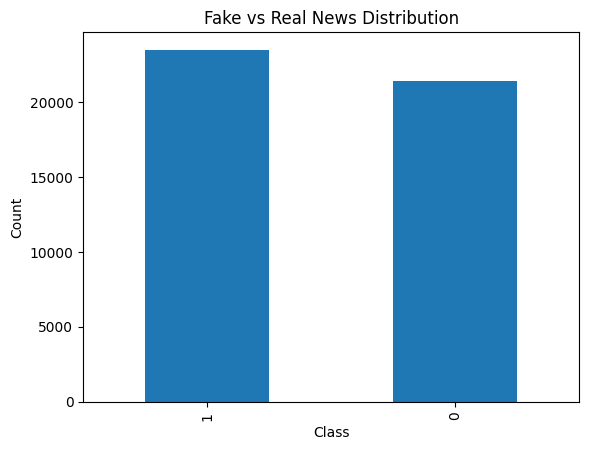

In [40]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Fake vs Real News Distribution")
plt.show()

Split Dataset (70:10:20)

In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df['text'], df['label'], test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.67, random_state=42)

TF-IDF Vectorization Train Model Logistic Regression

In [35]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.984819944598338

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      4307
           1       0.99      0.98      0.99      4718

    accuracy                           0.98      9025
   macro avg       0.98      0.98      0.98      9025
weighted avg       0.98      0.98      0.98      9025



In [34]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

Validation Check

In [38]:
val_pred = model.predict(X_val_tfidf)
print(f'Validation Accuracy: {accuracy_score(y_val, val_pred)}')

Validation Accuracy: 0.986726659167604


Final Testing

In [39]:
test_pred = model.predict(X_test_tfidf)

print("Test Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))

Test Accuracy: 0.984819944598338
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4307
           1       0.99      0.98      0.99      4718

    accuracy                           0.98      9025
   macro avg       0.98      0.98      0.98      9025
weighted avg       0.98      0.98      0.98      9025



Confusion matrix

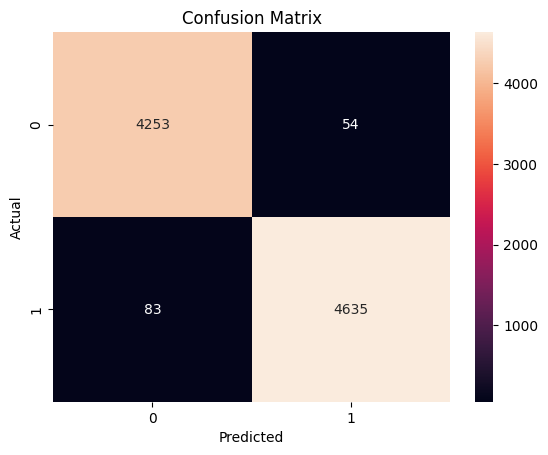

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Movie Recommendation System**

In [42]:
pip install pandas numpy scikit-learn matplotlib seaborn

Import Libraries


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor

Load Dataset

In [45]:
import zipfile

zip_path = "/content/ml-100k.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [46]:
import pandas as pd

ratings = pd.read_csv(
    "/content/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Data Visualization

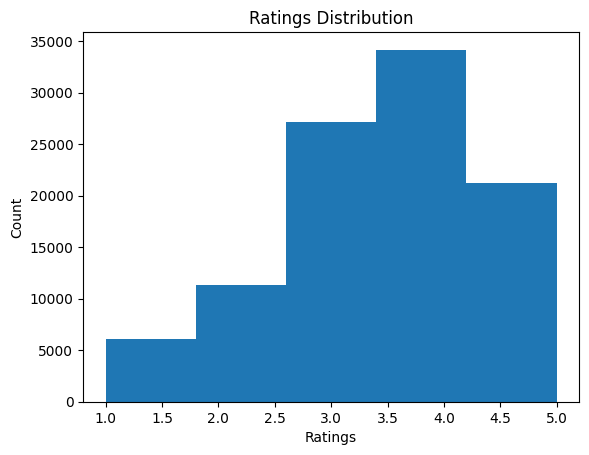

In [47]:
plt.hist(ratings['rating'], bins=5)
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.title("Ratings Distribution")
plt.show()

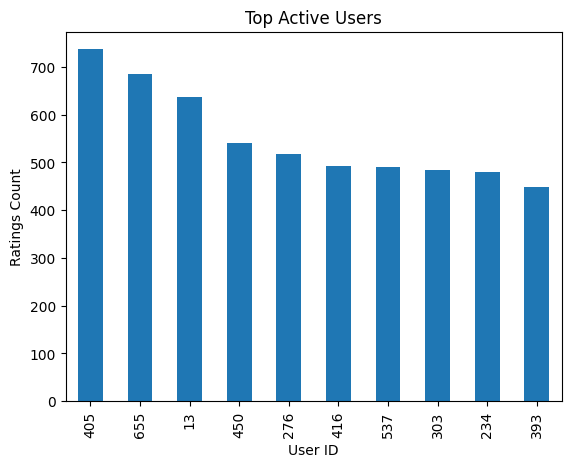

In [48]:
ratings['user_id'].value_counts().head(10).plot(kind='bar')
plt.title("Top Active Users")
plt.xlabel("User ID")
plt.ylabel("Ratings Count")
plt.show()

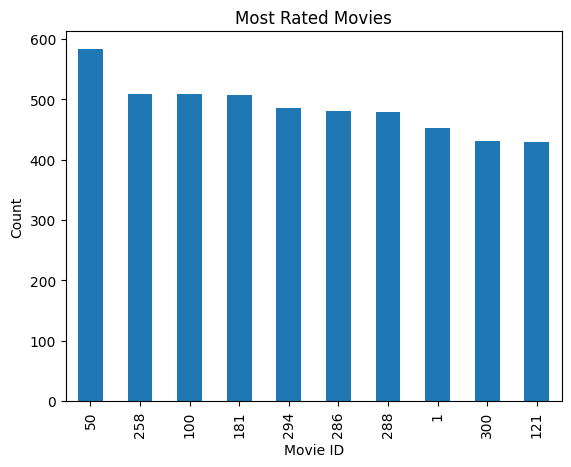

In [49]:
ratings['movie_id'].value_counts().head(10).plot(kind='bar')
plt.title("Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Count")
plt.show()

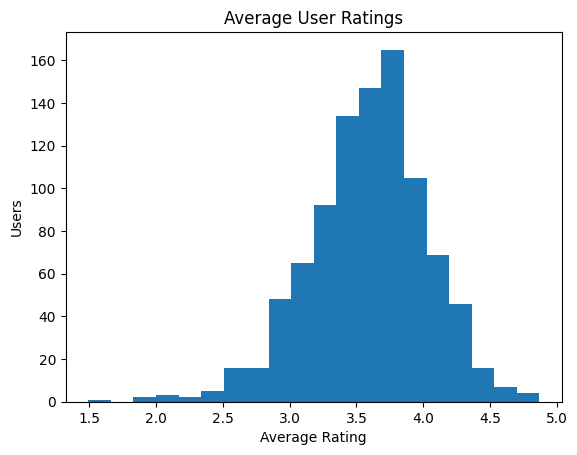

In [50]:
avg_user_rating = ratings.groupby('user_id')['rating'].mean()

plt.hist(avg_user_rating, bins=20)
plt.title("Average User Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Users")
plt.show()

Train/Validation/Test Split (70:10:20)

In [51]:
train, temp = train_test_split(
    ratings,
    test_size=0.30,
    random_state=42
)

val, test = train_test_split(
    temp,
    test_size=0.67,
    random_state=42
)

Features and Target

In [52]:
X_train = train[['user_id','movie_id']]
y_train = train['rating']

X_val = val[['user_id','movie_id']]
y_val = val['rating']

X_test = test[['user_id','movie_id']]
y_test = test['rating']

Train Model - KNN Models


In [53]:
model = KNeighborsRegressor(n_neighbors=5)

model.fit(X_train, y_train)

KNeighborsRegressor()

Validation

In [54]:
val_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, val_pred))
mae = mean_absolute_error(y_val, val_pred)

print("Validation RMSE:", rmse)
print("Validation MAE:", mae)

Validation RMSE: 1.1270162627778078
Validation MAE: 0.8958383838383838


Final Testing

In [55]:
test_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, test_pred))
mae = mean_absolute_error(y_test, test_pred)

print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 1.1219341863086087
Test MAE: 0.8935223880597016


Actual vs Predicted Plot

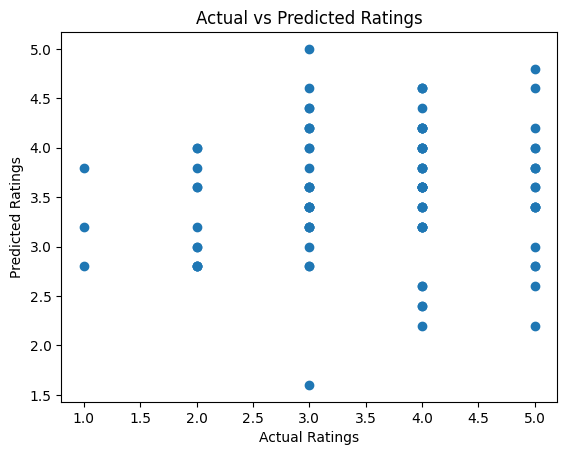

In [56]:
plt.scatter(y_test[:100], test_pred[:100])
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()